In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Angers"
away= "Toulouse"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Angers,Lens,2025-01-26,L,A,0,1,-1,36,0,...,0.1,0.1,-0.2,-0.2,-0.1,0.08,0,0.8,0.20,-0.2
19,Angers,Le Havre,2025-02-02,D,H,1,1,0,59,0,...,1.2,0.9,-0.3,-0.3,-0.2,0.09,1,1.9,0.39,0.9
20,Angers,Marseille,2025-02-09,L,H,0,2,-2,22,0,...,0.2,0.4,-0.5,-0.5,-0.2,0.10,0,2.6,0.33,0.6
21,Angers,Reims,2025-02-16,W,A,1,0,1,37,0,...,1.5,1.3,-0.5,-0.5,-1.5,0.16,1,0.2,0.05,0.2
22,Angers,Saint-Étienne,2025-02-22,D,A,3,3,0,39,2,...,0.8,0.5,0.1,-0.4,-0.8,0.13,0,1.9,0.25,-1.1


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Lens,Angers,2025-01-26,W,H,1,0,1,64,0,...,1.9,1.8,-0.9,-0.9,-0.9,0.12,0,0.0,NaN,0.0
19,Le Havre,Angers,2025-02-02,D,A,1,1,0,41,0,...,2.1,1.5,-1.2,-1.2,-1.1,0.17,0,1.2,0.39,0.2
20,Marseille,Angers,2025-02-09,W,A,2,0,2,78,0,...,1.9,2.0,-0.4,-0.4,0.1,0.14,0,0.0,NaN,0.0
21,Reims,Angers,2025-02-16,L,H,0,1,-1,63,1,...,0.5,0.9,-1.7,-0.9,-0.5,0.06,0,0.6,0.29,-0.4
22,Saint-Étienne,Angers,2025-02-22,D,H,3,3,0,61,0,...,1.3,1.7,1.5,1.5,1.7,0.09,0,2.5,0.22,-0.5


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Toulouse,Montpellier,2025-01-26,L,H,1,2,-1,66,0,...,1.0,1.6,0.0,0.0,0.0,0.07,0,2.2,0.54,0.2
19,Toulouse,Nice,2025-02-02,D,H,1,1,0,54,0,...,0.9,0.6,-0.4,-0.4,-0.9,0.10,0,1.4,0.16,0.4
20,Toulouse,Auxerre,2025-02-09,D,A,2,2,0,47,0,...,0.9,1.1,1.1,1.1,1.1,0.13,0,0.8,0.26,-1.2
21,Toulouse,Paris S-G,2025-02-15,L,H,0,1,-1,24,0,...,0.7,0.5,-0.9,-0.9,-0.7,0.06,0,1.8,0.39,0.8
22,Toulouse,Le Havre,2025-02-23,W,A,4,1,3,46,1,...,1.5,1.8,1.6,1.4,1.5,0.16,0,0.9,0.30,-0.1


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Montpellier,Toulouse,2025-01-26,W,A,2,1,1,34,0,...,0.4,0.4,1.5,1.5,0.6,0.09,0,0.8,0.16,-0.2
19,Nice,Toulouse,2025-02-02,D,A,1,1,0,46,1,...,0.6,0.8,-0.7,-0.9,-0.6,0.07,0,1.9,0.47,0.9
20,Auxerre,Toulouse,2025-02-09,D,H,2,2,0,53,0,...,0.9,0.5,1.1,1.1,1.1,0.10,0,1.3,0.42,-0.7
21,Paris S-G,Toulouse,2025-02-15,W,A,1,0,1,76,0,...,1.4,1.2,-1.4,-1.4,-1.4,0.13,2,0.5,0.12,0.5
22,Le Havre,Toulouse,2025-02-23,L,H,1,4,-3,54,0,...,0.6,0.7,0.2,0.2,0.4,0.07,0,2.9,0.41,-1.1


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,0,0,0,36,0,18,7,38.9,10,55.6,...,-1.7,-1.7,0.1,0.1,-0.2,-0.2,-0.1,0.08,0,0
19,1,0,0,59,0,15,7,46.7,6,40.0,...,-0.8,-0.8,1.2,0.9,-0.3,-0.3,-0.2,0.09,1,1
20,0,0,0,22,0,14,4,28.6,9,64.3,...,-1.9,-1.9,0.2,0.4,-0.5,-0.5,-0.2,0.10,0,0
21,1,0,0,37,0,18,8,44.4,9,50.0,...,-0.2,0.6,1.5,1.3,-0.5,-0.5,-1.5,0.16,1,1
22,1,2,0,39,2,19,11,57.9,6,31.6,...,1.5,-0.1,0.8,0.5,0.1,-0.4,-0.8,0.13,0,3


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,64,0,23,10,43.5,10,43.5,...,1.7,1.7,1.9,1.8,-0.9,-0.9,-0.9,0.12,0,1
19,1,0,0,41,0,16,7,43.8,7,43.8,...,0.8,0.8,2.1,1.5,-1.2,-1.2,-1.1,0.17,0,1
20,2,0,0,78,0,15,9,60.0,6,40.0,...,1.9,1.9,1.9,2.0,-0.4,-0.4,0.1,0.14,0,2
21,0,0,1,63,1,19,7,36.8,9,47.4,...,0.2,-0.6,0.5,0.9,-1.7,-0.9,-0.5,0.06,0,0
22,3,0,0,61,0,21,12,57.1,9,42.9,...,-1.5,0.1,1.3,1.7,1.5,1.5,1.7,0.09,0,3


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,66,0,21,13,61.9,7,33.3,...,0.4,0.4,1.0,1.6,0.0,0.0,0.0,0.07,0,1
19,1,0,0,54,0,24,11,45.8,11,45.8,...,-0.2,0.6,0.9,0.6,-0.4,-0.4,-0.9,0.10,0,1
20,2,0,0,47,0,10,4,40.0,6,60.0,...,0.0,0.0,0.9,1.1,1.1,1.1,1.1,0.13,0,2
21,0,0,0,24,0,19,8,42.1,11,57.9,...,-1.5,-1.5,0.7,0.5,-0.9,-0.9,-0.7,0.06,0,0
22,3,1,0,46,1,23,7,30.4,13,56.5,...,1.6,0.8,1.5,1.8,1.6,1.4,1.5,0.16,0,4


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,2,0,0,34,0,14,5,35.7,9,64.3,...,-0.4,-0.4,0.4,0.4,1.5,1.5,0.6,0.09,0,2
19,0,1,0,46,1,14,5,35.7,7,50.0,...,0.2,-0.6,0.6,0.8,-0.7,-0.9,-0.6,0.07,0,1
20,2,0,0,53,0,18,8,44.4,10,55.6,...,0.0,0.0,0.9,0.5,1.1,1.1,1.1,0.10,0,2
21,1,0,0,76,0,25,12,48.0,12,48.0,...,1.5,1.5,1.4,1.2,-1.4,-1.4,-1.4,0.13,2,1
22,1,0,0,54,0,25,7,28.0,15,60.0,...,-1.6,-0.8,0.6,0.7,0.2,0.2,0.4,0.07,0,1


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,20,2,10.0,0,0,7.0,0,NaN,0,0,...,3,9,12,37,27,0,0.8,0.20,-0.2,1
19,16,1,6.3,0,1,12.5,0,NaN,0,0,...,4,5,7,17,27,0,1.9,0.39,0.9,1
20,20,0,0.0,0,2,15.0,0,NaN,0,1,...,4,11,11,26,26,0,2.6,0.33,0.6,2
21,18,3,16.7,1,0,7.3,0,NaN,0,0,...,6,10,10,28,31,0,0.2,0.05,0.2,0
22,20,2,10.0,0,0,6.3,0,NaN,0,1,...,6,9,8,26,31,0,1.9,0.25,-1.1,3


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,10,1,10.0,0,0,6.0,0,NaN,0,0,...,2,8,13,34,13,0,0.0,NaN,0.0,0
19,20,2,10.0,0,2,19.3,0,NaN,0,0,...,6,4,8,21,34,0,1.2,0.39,0.2,1
20,7,0,0.0,0,0,17.0,0,NaN,0,0,...,2,6,4,20,10,1,0.0,NaN,0.0,0
21,18,1,5.6,0,1,12.5,0,NaN,1,0,...,2,6,14,27,39,0,0.6,0.29,-0.4,1
22,10,1,10.0,2,2,14.0,0,0.0,0,0,...,0,9,7,24,18,0,2.5,0.22,-0.5,3


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,16,1,6.3,0,0,10.3,0,NaN,0,0,...,3,3,8,28,20,0,0.8,0.40,0.8,0
1,12,1,8.3,0,2,14.7,0,NaN,0,0,...,2,7,5,31,19,0,0.6,0.21,-0.4,1
2,10,0,0.0,0,0,14.8,0,NaN,0,0,...,5,6,9,23,16,1,0.7,0.18,-1.3,3
3,11,0,0.0,0,0,9.0,0,NaN,0,0,...,1,7,8,27,17,0,0.7,0.25,0.7,0
4,15,0,0.0,0,1,18.5,0,NaN,0,0,...,2,6,10,32,18,0,0.6,0.12,-1.4,2


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,20,2,10.0,0,0,4.6,0,NaN,0,0,...,3,7,5,23,33,0,1.3,0.22,1.3,0
1,12,3,25.0,0,0,5.3,0,NaN,0,0,...,5,12,6,25,12,2,1.1,0.36,0.1,1
2,6,0,0.0,0,4,25.0,0,NaN,0,0,...,0,3,7,22,11,1,1.0,1.00,0.0,1
3,15,1,6.7,0,1,10.2,0,NaN,0,0,...,4,9,13,33,27,1,2.0,0.34,0.0,2
4,20,0,0.0,1,0,11.0,0,NaN,0,0,...,1,6,13,25,35,0,0.1,0.06,0.1,0


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,6,17,26.1,1,0,0,10,16,52
19,6,11,35.3,2,1,0,8,19,38
20,7,11,38.9,1,0,0,10,7,38
21,10,8,55.6,1,0,0,6,13,39
22,8,17,32.0,0,0,0,16,12,43


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,17,6,73.9,1,0,0,16,10,58
19,11,6,64.7,4,1,0,19,8,31
20,11,7,61.1,2,0,0,8,10,43
21,8,10,44.4,2,0,0,13,6,50
22,17,8,68.0,3,0,0,13,15,46


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,10,15,40.0,1,0,0,9,12,51
19,13,12,52.0,2,0,0,20,20,42
20,13,11,54.2,1,0,0,9,10,38
21,5,12,29.4,2,0,0,9,4,45
22,12,17,41.4,2,0,0,13,11,36


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,15,10,60.0,2,0,0,15,8,45
19,12,13,48.0,2,0,0,20,19,41
20,11,13,45.8,1,0,0,11,9,43
21,12,5,70.6,0,0,0,6,8,47
22,17,12,58.6,0,1,0,11,13,44


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,0,0,0,36,0,18,7,38.9,10,55.6,...,-0.225,0.464579,-0.175,0.727438,0.1575,0.074106,0.50,1.000000,1.75,1.258306
19,1,0,0,59,0,15,7,46.7,6,40.0,...,-0.175,0.450000,-0.100,0.711805,0.1475,0.083016,0.50,1.000000,1.75,1.258306
20,0,0,0,22,0,14,4,28.6,9,64.3,...,-0.300,0.374166,-0.275,0.590903,0.1075,0.048563,0.75,0.957427,1.50,1.290994
21,1,0,0,37,0,18,8,44.4,9,50.0,...,-0.225,0.250000,-0.050,0.238048,0.0875,0.009574,0.75,0.957427,0.75,0.957427
22,1,2,0,39,2,19,11,57.9,6,31.6,...,-0.375,0.150000,-0.500,0.668331,0.1075,0.035940,0.50,0.577350,0.50,0.577350


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,64,0,23,10,43.5,10,43.5,...,-0.175,1.078193,-0.275,0.579511,0.0725,0.009574,0.25,0.5,0.75,0.957427
19,1,0,0,41,0,16,7,43.8,7,43.8,...,-0.750,0.264575,-0.625,0.320156,0.0825,0.026300,0.25,0.5,0.50,0.577350
20,2,0,0,78,0,15,9,60.0,6,40.0,...,-0.800,0.336650,-0.675,0.386221,0.1050,0.050662,0.25,0.5,0.75,0.500000
21,0,0,1,63,1,19,7,36.8,9,47.4,...,-0.800,0.336650,-0.575,0.537742,0.1250,0.042032,0.25,0.5,1.00,0.816497
22,3,0,0,61,0,21,12,57.1,9,42.9,...,-0.850,0.331662,-0.600,0.529150,0.1225,0.046458,0.00,0.0,1.00,0.816497


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,5,0,0.0,0,2,20.7,0,0.0,0,0,...,0.25,0.500000,0.70,0.871780,0.3575,0.431770,-0.05,0.378594,0.75,0.957427
19,9,0,0.0,1,1,17.0,0,0.0,0,0,...,0.75,0.957427,1.15,1.100000,0.4425,0.423822,0.15,0.100000,1.00,1.154701
20,9,1,11.1,0,2,18.0,0,0.0,0,1,...,1.00,0.816497,1.45,0.900000,0.4425,0.423822,0.20,0.163299,1.25,0.957427
21,9,0,0.0,0,0,5.0,0,0.0,0,1,...,0.75,0.957427,1.15,0.854400,0.2575,0.203695,-0.10,0.739369,1.25,0.957427
22,26,0,0.0,0,0,11.0,0,0.0,0,0,...,0.75,0.957427,1.55,0.597216,0.3375,0.164595,0.05,0.869866,1.50,0.577350


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,18,1,5.6,0,1,12.2,0,0.0,0,0,...,0.50,0.57735,1.000,1.095445,0.1925,0.182094,0.250,1.360147,1.00,0.816497
19,20,0,0.0,0,0,5.0,0,0.0,0,0,...,0.25,0.50000,1.100,1.039230,0.2075,0.174236,0.600,0.783156,0.75,0.500000
20,13,0,0.0,0,0,14.0,0,0.0,0,1,...,0.50,0.57735,0.925,0.708872,0.2100,0.179072,0.425,0.518813,0.75,0.500000
21,10,2,20.0,0,1,14.0,0,0.0,0,0,...,0.25,0.50000,1.050,0.723418,0.2775,0.198725,0.050,0.675771,1.00,0.816497
22,6,1,16.7,1,1,16.0,0,0.0,0,0,...,0.50,0.57735,1.125,0.613052,0.2925,0.178022,0.125,0.713559,1.00,0.816497


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,66,0,21,13,61.9,7,33.3,...,-0.725,0.884590,-0.650,0.842615,0.1175,0.048563,0.5,1.0,1.00,0.816497
19,1,0,0,54,0,24,11,45.8,11,45.8,...,-0.875,0.585235,-0.800,0.547723,0.1025,0.052520,0.5,1.0,0.75,0.500000
20,2,0,0,47,0,10,4,40.0,6,60.0,...,-0.675,0.573730,-0.725,0.492443,0.0825,0.015000,0.5,1.0,0.75,0.500000
21,0,0,0,24,0,19,8,42.1,11,57.9,...,-0.100,0.920145,-0.225,1.004573,0.0975,0.025000,0.0,0.0,1.00,0.816497
22,3,1,0,46,1,23,7,30.4,13,56.5,...,-0.050,0.850490,-0.125,0.903235,0.0900,0.031623,0.0,0.0,1.00,0.816497


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,2,0,0,34,0,14,5,35.7,9,64.3,...,-0.475,0.793200,-0.275,0.550000,0.1575,0.097767,0.25,0.5,0.75,0.957427
19,0,1,0,46,1,14,5,35.7,7,50.0,...,-0.225,1.236595,-0.250,0.597216,0.1375,0.102429,0.25,0.5,1.00,1.154701
20,2,0,0,53,0,18,8,44.4,10,55.6,...,-0.100,1.095445,-0.200,0.541603,0.1300,0.107083,0.25,0.5,1.25,0.957427
21,1,0,0,76,0,25,12,48.0,12,48.0,...,0.250,1.226105,0.175,0.809835,0.0825,0.015000,0.25,0.5,1.25,0.957427
22,1,0,0,54,0,25,7,28.0,15,60.0,...,0.075,1.438460,-0.075,1.135415,0.0975,0.025000,0.50,1.0,1.50,0.577350


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,20,2,10.0,0,0,7.0,0,0.0,0,0,...,0.50,0.57735,1.225,0.394757,0.2550,0.152862,0.475,1.150000,0.75,0.957427
19,16,1,6.3,0,1,12.5,0,0.0,0,0,...,0.25,0.50000,1.150,0.450925,0.2375,0.154569,0.650,0.896289,0.50,0.577350
20,20,0,0.0,0,2,15.0,0,0.0,0,1,...,0.25,0.50000,1.175,0.499166,0.2225,0.127639,0.425,0.561991,0.75,0.500000
21,18,3,16.7,1,0,7.3,0,0.0,0,0,...,0.25,0.50000,1.550,0.858293,0.2850,0.090370,0.550,0.519615,1.00,0.816497
22,20,2,10.0,0,0,6.3,0,0.0,0,1,...,0.00,0.00000,1.375,1.078193,0.2425,0.150859,0.375,0.478714,1.00,0.816497


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,10,1,10.0,0,0,6.0,0,0.0,0,0,...,1.50,1.290994,1.825,1.824600,0.583333,0.353034,0.325,0.655108,1.75,1.258306
19,20,2,10.0,0,2,19.3,0,0.0,0,0,...,1.50,1.290994,1.825,1.824600,0.583333,0.353034,0.325,0.655108,1.75,1.258306
20,7,0,0.0,0,0,17.0,0,0.0,0,0,...,1.25,1.500000,1.650,1.848423,0.393333,0.135031,0.400,0.605530,1.50,1.290994
21,18,1,5.6,0,1,12.5,0,0.0,1,0,...,0.75,0.957427,0.575,0.665207,0.325000,0.091924,0.075,0.095743,0.75,0.957427
22,10,1,10.0,2,2,14.0,0,0.0,0,0,...,0.25,0.500000,0.450,0.574456,0.340000,0.070711,-0.050,0.251661,0.50,0.577350


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
18,6,17,26.1,1,0,0,10,16,52,13.50,...,0.00,0.0,0.0,0.0,12.50,2.645751,12.00,4.082483,42.25,6.701990
19,6,11,35.3,2,1,0,8,19,38,12.50,...,0.00,0.0,0.0,0.0,12.00,2.943920,11.50,3.109126,44.25,8.381527
20,7,11,38.9,1,0,0,10,7,38,10.25,...,0.25,0.5,0.0,0.0,10.50,3.109126,14.00,4.242641,45.50,6.244998
21,10,8,55.6,1,0,0,6,13,39,8.25,...,0.25,0.5,0.0,0.0,9.25,0.957427,13.00,5.477226,44.25,7.320064
22,8,17,32.0,0,0,0,16,12,43,7.25,...,0.25,0.5,0.0,0.0,8.50,1.914854,13.75,5.123475,41.75,6.849574


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
18,17,6,73.9,1,0,0,16,10,58,12.50,...,0.75,0.957427,0.25,0.5,12.50,3.696846,11.50,1.914854,42.75,2.500000
19,11,6,64.7,4,1,0,19,8,31,14.25,...,0.75,0.957427,0.25,0.5,12.00,2.708013,11.25,2.061553,46.25,8.180261
20,11,7,61.1,2,0,0,8,10,43,12.25,...,1.00,0.816497,0.25,0.5,14.00,4.242641,10.00,2.160247,43.00,11.343133
21,8,10,44.4,2,0,0,13,6,50,11.75,...,0.50,0.577350,0.00,0.0,13.25,5.123475,9.25,0.957427,42.75,11.324752
22,17,8,68.0,3,0,0,13,15,46,11.75,...,0.25,0.500000,0.00,0.0,14.00,4.690416,8.50,1.914854,45.50,11.445523


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
18,10,15,40.0,1,0,0,9,12,51,10.75,...,0.0,0.0,0.0,0.0,12.00,3.265986,13.75,4.573474,49.00,2.581989
19,13,12,52.0,2,0,0,20,20,42,9.25,...,0.0,0.0,0.0,0.0,10.25,2.061553,13.00,4.546061,49.75,2.629956
20,13,11,54.2,1,0,0,9,10,38,11.00,...,0.0,0.0,0.0,0.0,12.25,5.439056,13.25,4.991660,47.75,4.645787
21,5,12,29.4,2,0,0,9,4,45,11.50,...,0.0,0.0,0.0,0.0,11.50,5.686241,12.50,5.259911,44.25,5.560276
22,12,17,41.4,2,0,0,13,11,36,10.25,...,0.0,0.0,0.0,0.0,11.75,5.500000,11.50,6.608076,44.00,5.477226


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
18,15,10,60.0,2,0,0,15,8,45,12.00,...,0.25,0.5,0.0,0.0,14.25,4.924429,11.25,2.500000,46.75,4.924429
19,12,13,48.0,2,0,0,20,19,41,12.00,...,0.25,0.5,0.0,0.0,14.25,4.924429,9.75,2.061553,47.50,4.123106
20,11,13,45.8,1,0,0,11,9,43,12.25,...,0.00,0.0,0.0,0.0,14.25,4.924429,11.75,5.188127,45.00,4.320494
21,12,5,70.6,0,0,0,6,8,47,11.50,...,0.00,0.0,0.0,0.0,13.50,5.196152,11.00,5.354126,45.00,4.320494
22,17,12,58.6,0,1,0,11,13,44,12.50,...,0.00,0.0,0.0,0.0,13.00,5.944185,11.00,5.354126,44.00,2.581989


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,1,2,0,39,2,19,11,57.9,6,31.6,...,0.957427,1.55,0.597216,0.3375,0.164595,0.05,0.869866,1.5,0.57735,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,42,0,24,8,33.3,15,62.5,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,0,0,0,36,0,16,5,31.3,11,68.8,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,40.000000,0.000000,H,1
2,0,1,0,54,1,19,11,57.9,6,31.6,...,0.0,0.0,17.50,4.949747,10.500000,0.707107,41.000000,1.414214,A,1
3,1,0,0,48,0,20,5,25.0,14,70.0,...,0.0,0.0,15.00,5.567764,11.333333,1.527525,39.333333,3.055050,H,1
4,0,1,0,50,1,24,9,37.5,15,62.5,...,0.0,0.0,13.75,5.188127,11.250000,1.258306,44.000000,9.660918,H,1


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,20,2,10.0,0,0,6.3,0,0.0,0,1,...,0.0,0.0,0.0,11.75,5.5,11.5,6.608076,44.0,5.477226,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,13,2,15.4,0,3,15.2,0,0.0,0,0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,2
1,11,2,18.2,0,0,10.7,0,0.0,0,0,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,40.000000,0.000000,H,4
2,10,0,0.0,0,0,12.0,0,0.0,0,1,...,0.0,0.0,17.50,4.949747,10.500000,0.707107,41.000000,1.414214,A,1
3,11,1,9.1,0,0,8.4,0,0.0,0,0,...,0.0,0.0,15.00,5.567764,11.333333,1.527525,39.333333,3.055050,H,1
4,12,2,16.7,0,0,7.5,0,0.0,0,0,...,0.0,0.0,13.75,5.188127,11.250000,1.258306,44.000000,9.660918,H,3


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,3,1,0,46,1,23,7,30.4,13,56.5,...,0.0,0.0,0.0,11.75,5.5,11.5,6.608076,44.0,5.477226,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,54,0,13,5,38.5,7,53.8,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,1,0,0,43,0,21,9,42.9,12,57.1,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,40.000000,0.000000,H,1
2,1,0,0,24,0,11,3,27.3,8,72.7,...,0.0,0.0,17.50,4.949747,10.500000,0.707107,41.000000,1.414214,H,2
3,2,0,0,54,0,19,11,57.9,5,26.3,...,0.0,0.0,15.00,5.567764,11.333333,1.527525,39.333333,3.055050,A,0
4,0,0,1,57,1,8,4,50.0,4,50.0,...,0.0,0.0,13.75,5.188127,11.250000,1.258306,44.000000,9.660918,H,1


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,26,0,0.0,0,0,11.0,0,0.0,0,0,...,0.0,0.0,0.0,11.75,5.5,11.5,6.608076,44.0,5.477226,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,16,1,6.3,0,0,10.3,0,0.0,0,0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,12,1,8.3,0,2,14.7,0,0.0,0,0,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,40.000000,0.000000,H,3
2,10,0,0.0,0,0,14.8,0,0.0,0,0,...,0.0,0.0,17.50,4.949747,10.500000,0.707107,41.000000,1.414214,H,0
3,11,0,0.0,0,0,9.0,0,0.0,0,0,...,0.0,0.0,15.00,5.567764,11.333333,1.527525,39.333333,3.055050,A,2
4,15,0,0.0,0,1,18.5,0,0.0,0,0,...,0.0,0.0,13.75,5.188127,11.250000,1.258306,44.000000,9.660918,H,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

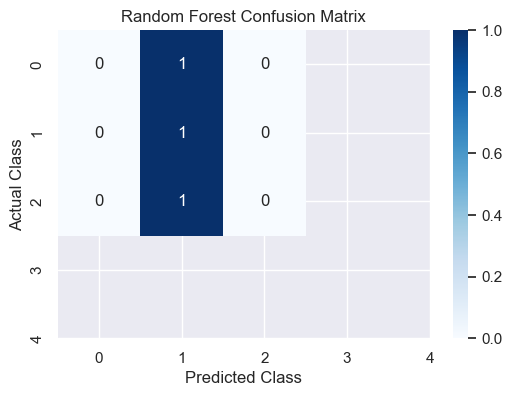

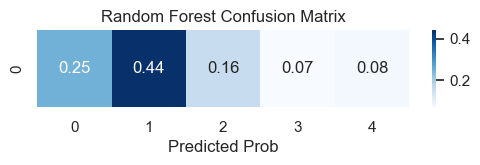

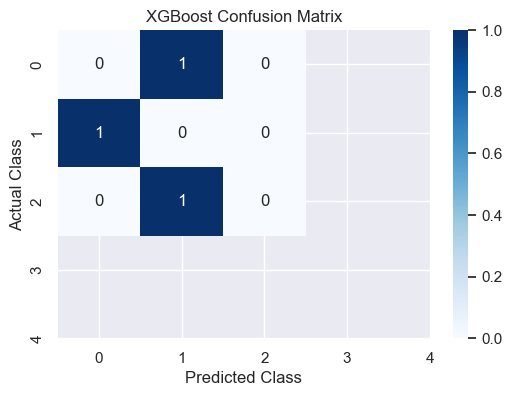

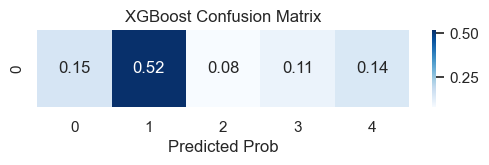

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

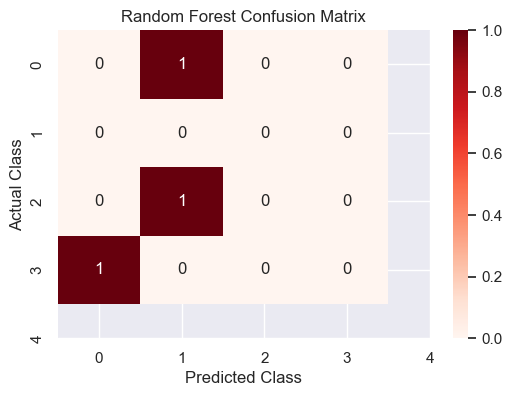

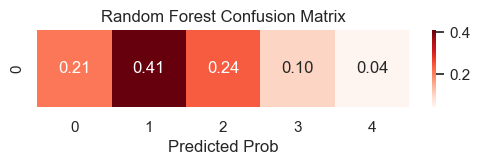

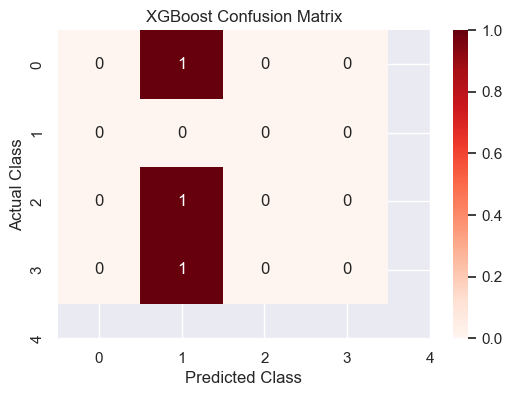

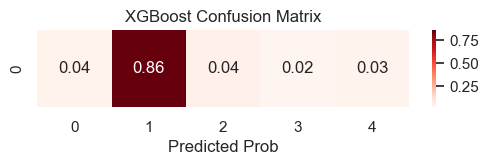

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

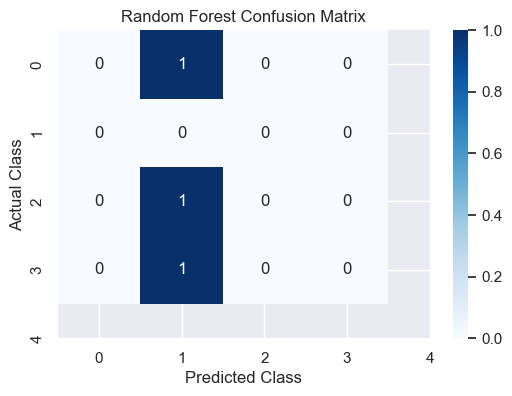

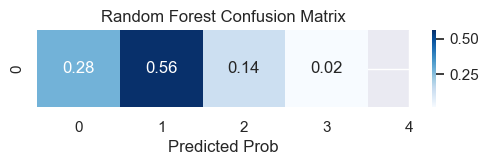

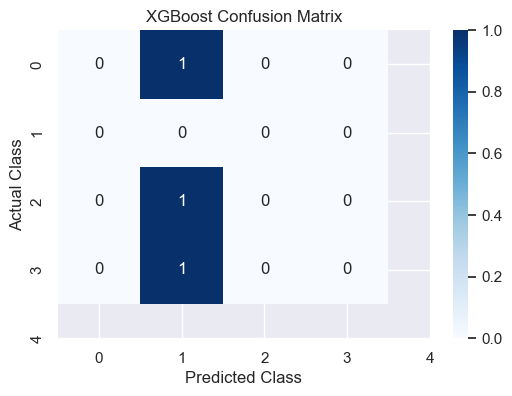

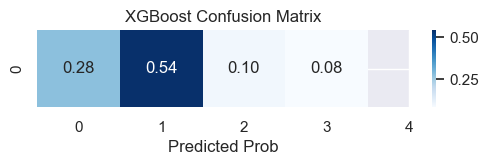

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

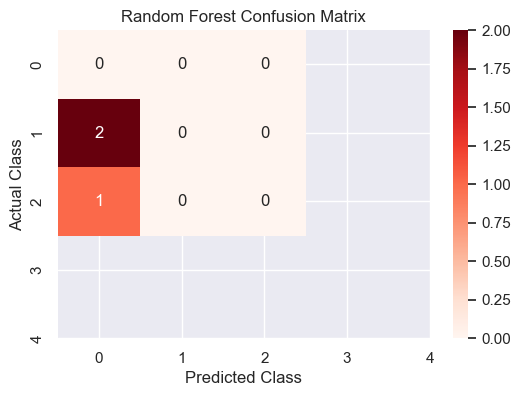

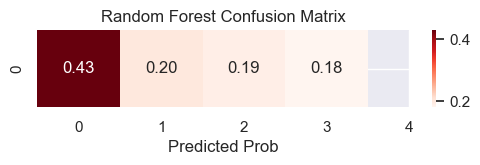

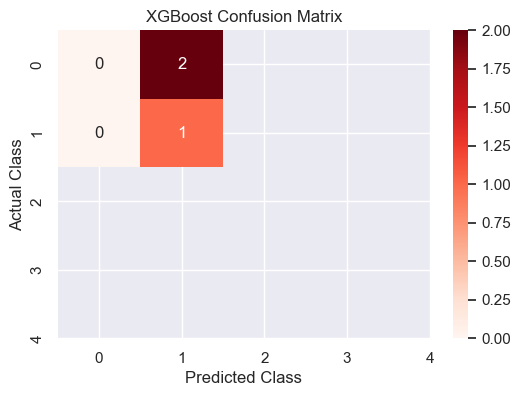

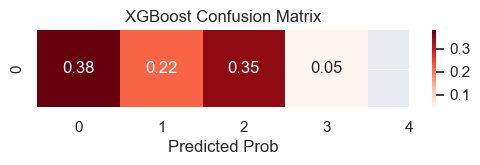

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

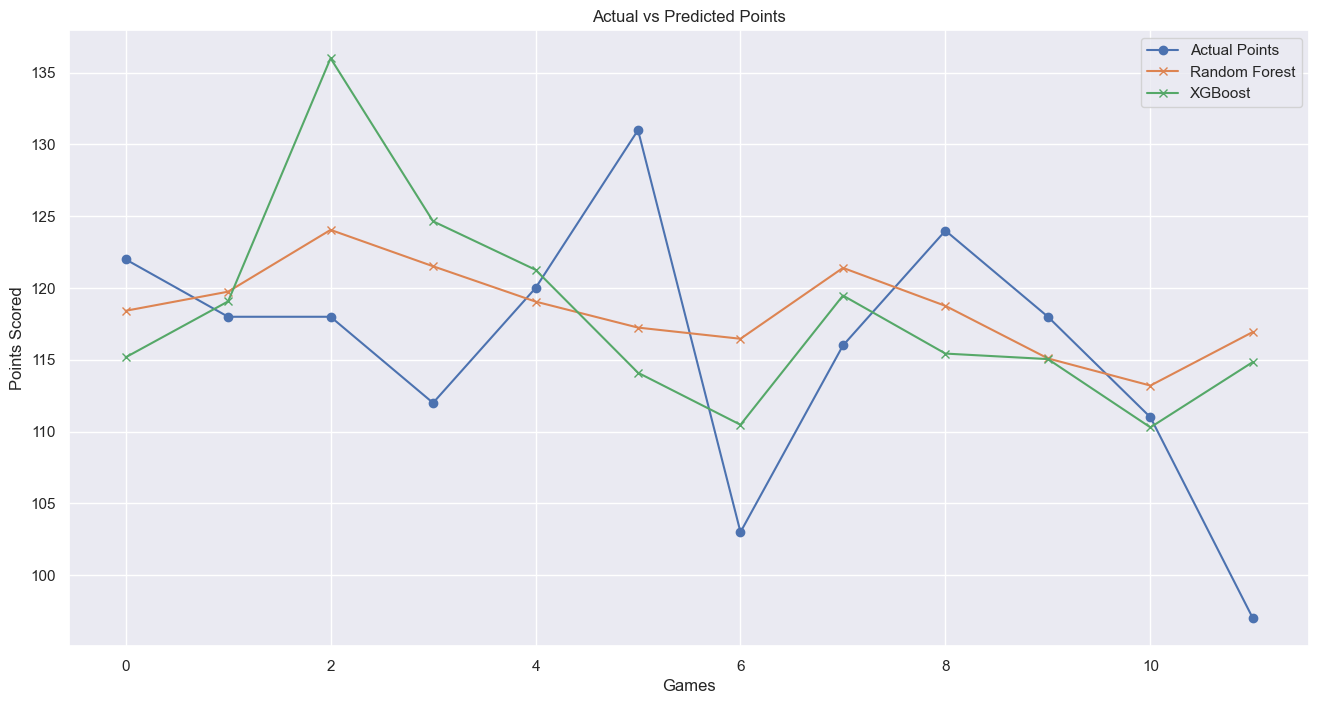

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
